In [11]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir) 

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [12]:
import functools
import torch
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import degree
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx

from bcosgnn.explain import explain
from bcosgnn.evaluation import evaluate_auroc, evaluate_jaccard
from bcosgnn.sanitized_models import BCosGNN, BcosGINConv, ReadoutThenAgg

## Dataset loading

In [13]:
import torch
import os
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


raw_data_path = "/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt"
print(f"Loading data directly from: {raw_data_path}")



dataset_list = torch.load(raw_data_path, weights_only=False)
print(f"Successfully loaded {len(dataset_list)} graphs.")

for i, data in enumerate(dataset_list):
    data.y = torch.tensor([0]) if i < 500 else torch.tensor([1])
    data.x = torch.ones((data.num_nodes, 1))

first_graph = dataset_list[0]
num_features = first_graph.num_features
all_labels = torch.cat([d.y for d in dataset_list])
num_classes = len(all_labels.unique())

print(f'Number of graphs: {len(dataset_list)}')
print(f'Number of features: {num_features}')
print(f'Number of classes: {num_classes}')


train_split_idx, test_split_idx = train_test_split(
    np.arange(len(dataset_list)), test_size=0.2, train_size=0.8, random_state=42
)

train_dataset = [dataset_list[i] for i in train_split_idx]
test_dataset = [dataset_list[i] for i in test_split_idx]

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loading data directly from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200


In [14]:
from bcosgnn.explain import explain
from bcosgnn.evaluation import (
    evaluate_auroc,
    evaluate_jaccard,
 )

## Train B-COS GIN (sanitized module) (B-Cos, B-Cos)

In [20]:
import random
from sklearn.metrics import roc_auc_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_one_hot_degree_clamped(data, max_degree=4):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(
        deg, num_classes=max_degree + 1
    ).to(torch.float)
    data.x = one_hot_deg.float()
    return data

def split_train_val_test(dataset, seed, test_size=0.2, val_size=0.1):
    labels = np.array([int(d.y.item()) for d in dataset])
    indices = np.arange(len(dataset))

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=seed,
        stratify=labels,
    )

    train_val_labels = labels[train_val_idx]
    val_ratio_on_trainval = val_size / (1.0 - test_size)
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_ratio_on_trainval,
        random_state=seed,
        stratify=train_val_labels,
    )

    train_data = [dataset[i] for i in train_idx]
    val_data = [dataset[i] for i in val_idx]
    test_data = [dataset[i] for i in test_idx]
    return train_data, val_data, test_data

def make_loader(data_list, transform, batch_size=64, shuffle=False):
    data_t = [transform(d.clone()) for d in data_list]
    return DataLoader(data_t, batch_size=batch_size, shuffle=shuffle)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_graphs = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch).flatten()
        loss = criterion(logits, batch.y.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = (logits > 0).long()
        total_loss += float(loss.item()) * batch.num_graphs
        total_correct += int((pred == batch.y.long()).sum().item())
        total_graphs += int(batch.num_graphs)

    return total_loss / total_graphs, total_correct / total_graphs

@torch.inference_mode()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_graphs = 0
    all_logits = []
    all_labels = []

    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch).flatten()
        loss = criterion(logits, batch.y.float())
        pred = (logits > 0).long()

        total_loss += float(loss.item()) * batch.num_graphs
        total_correct += int((pred == batch.y.long()).sum().item())
        total_graphs += int(batch.num_graphs)

        all_logits.append(logits.detach().cpu())
        all_labels.append(batch.y.detach().cpu().long())

    logits_all = torch.cat(all_logits).numpy()
    labels_all = torch.cat(all_labels).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits_all))
    try:
        clf_auroc = float(roc_auc_score(labels_all, probs))
    except ValueError:
        clf_auroc = float("nan")

    return {
        "loss": total_loss / total_graphs,
        "acc": total_correct / total_graphs,
        "clf_auroc": clf_auroc,
    }

class EvalModelAdapter(torch.nn.Module):
    def __init__(self, base_model: torch.nn.Module):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        return self.base_model(x, edge_index, batch)

max_degree = 4
transform = functools.partial(get_one_hot_degree_clamped, max_degree=max_degree)

SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 200
BATCH_SIZE = 64
LR = 3e-4
b = 2.0

seed_results = []
best_result = None
best_result_score = -float("inf")

for seed in SEEDS:
    print("=" * 80)
    print(f"Seed {seed}")
    print("=" * 80)
    set_seed(seed)

    train_data, val_data, test_data = split_train_val_test(
        dataset_list, seed=seed, test_size=0.2, val_size=0.1
    )

    train_loader = make_loader(train_data, transform, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_loader(val_data, transform, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_loader(test_data, transform, batch_size=BATCH_SIZE, shuffle=False)

    readout = ReadoutThenAgg(
        in_channels=64,
        hidden_channels=[64, 64],
        out_channels=1,
        b=b,
        max_out=1,
        agg="sum",
    )

    model = BCosGNN(
        node_size=max_degree + 1,
        hidden_channels=[64, 64],
        conv_layer=BcosGINConv,
        num_convs=3,
        readout=readout,
        b=b,
        max_out=1,
    ).to(DEVICE)

    criterion = BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
    )

    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    history = []

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate_loader(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        history.append(
            {
                "epoch": epoch,
                "train_loss": tr_loss,
                "train_acc": tr_acc,
                "val_loss": val_metrics["loss"],
                "val_acc": val_metrics["acc"],
                "val_clf_auroc": val_metrics["clf_auroc"],
                "lr": optimizer.param_groups[0]["lr"],
            }
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
                f"| val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} "
                f"| lr={optimizer.param_groups[0]['lr']:.2e}"
            )

    model.load_state_dict(best_state)
    eval_model = EvalModelAdapter(model).to(DEVICE)

    test_metrics = evaluate_loader(model, test_loader, criterion)
    test_jaccard = float(evaluate_jaccard(eval_model, test_data, method="explain", transform=transform))
    test_expl_auroc = float(evaluate_auroc(eval_model, test_data, method="explain", transform=transform))

    result = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_loss": float(best_val_loss),
        "test_loss": float(test_metrics["loss"]),
        "test_acc": float(test_metrics["acc"]),
        "test_clf_auroc": float(test_metrics["clf_auroc"]),
        "test_expl_auroc": test_expl_auroc,
        "test_jaccard": test_jaccard,
        "history": history,
        "model": model,
        "eval_model": eval_model,
        "test_dataset": test_data,
    }
    seed_results.append(result)

    print(
        f"Seed {seed} | best_epoch={best_epoch} | test_acc={result['test_acc']:.4f} "
        f"| test_clf_auroc={result['test_clf_auroc']:.4f} "
        f"| test_expl_auroc={result['test_expl_auroc']:.4f} "
        f"| test_jaccard={result['test_jaccard']:.4f}"
    )

    rank_score = float(
        np.nan_to_num(result["test_expl_auroc"], nan=-1e9)
        + np.nan_to_num(result["test_jaccard"], nan=-1e9)
    )
    if (best_result is None) or (rank_score > best_result_score):
        best_result_score = rank_score
        best_result = result

metrics_keys = [
    "test_loss",
    "test_acc",
    "test_clf_auroc",
    "test_expl_auroc",
    "test_jaccard",
]

summary = {}
for key in metrics_keys:
    vals = np.array([r[key] for r in seed_results], dtype=float)
    summary[f"{key}_mean"] = float(np.nanmean(vals))
    summary[f"{key}_std"] = float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else 0.0

df_seed_results = pl.DataFrame([
    {k: v for k, v in r.items() if k in ["seed", "best_epoch", "best_val_loss", *metrics_keys]}
    for r in seed_results
])
df_summary = pl.DataFrame([summary])

print("\nPer-seed test metrics:")
display(df_seed_results)
print("\nMean ± std across 3 seeds:")
display(df_summary)

if best_result is None:
    raise RuntimeError("No valid seed result was produced. Check training/evaluation logs.")

# Keep these names for downstream cells
model = best_result["model"]
eval_model = best_result["eval_model"]
test_dataset = best_result["test_dataset"]
print("\nUsing best seed model for qualitative plots:", best_result["seed"])

Device: cpu
Seed 0
Epoch 001 | train_loss=0.6888 train_acc=0.7714 | val_loss=0.6778 val_acc=0.8400 | lr=3.00e-04
Epoch 001 | train_loss=0.6888 train_acc=0.7714 | val_loss=0.6778 val_acc=0.8400 | lr=3.00e-04
Epoch 005 | train_loss=0.1915 train_acc=0.9357 | val_loss=0.0871 val_acc=0.9900 | lr=3.00e-04
Epoch 005 | train_loss=0.1915 train_acc=0.9357 | val_loss=0.0871 val_acc=0.9900 | lr=3.00e-04
Epoch 010 | train_loss=0.0016 train_acc=1.0000 | val_loss=0.0017 val_acc=1.0000 | lr=3.00e-04
Epoch 010 | train_loss=0.0016 train_acc=1.0000 | val_loss=0.0017 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0006 train_acc=1.0000 | val_loss=0.0007 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0006 train_acc=1.0000 | val_loss=0.0007 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0003 train_acc=1.0000 | val_loss=0.0004 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0003 train_acc=1.0000 | val_loss=0.0004 val_acc=1.0000 | lr=3.00e-04
Epoch 025 | train_loss=0.0002 train_acc=1

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 693.37it/s]



Seed 0 | best_epoch=200 | test_acc=1.0000 | test_clf_auroc=1.0000 | test_expl_auroc=0.9942 | test_jaccard=0.8883
Seed 1
Epoch 001 | train_loss=0.6845 train_acc=0.5100 | val_loss=0.6678 val_acc=0.5000 | lr=3.00e-04
Epoch 005 | train_loss=0.1864 train_acc=0.9614 | val_loss=0.1251 val_acc=0.9900 | lr=3.00e-04
Epoch 005 | train_loss=0.1864 train_acc=0.9614 | val_loss=0.1251 val_acc=0.9900 | lr=3.00e-04
Epoch 010 | train_loss=0.0024 train_acc=1.0000 | val_loss=0.0026 val_acc=1.0000 | lr=3.00e-04
Epoch 010 | train_loss=0.0024 train_acc=1.0000 | val_loss=0.0026 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0010 train_acc=1.0000 | val_loss=0.0008 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0010 train_acc=1.0000 | val_loss=0.0008 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0003 train_acc=1.0000 | val_loss=0.0004 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0003 train_acc=1.0000 | val_loss=0.0004 val_acc=1.0000 | lr=3.00e-04
Epoch 025 | train_loss=0.0002 trai

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 696.70it/s]



Seed 1 | best_epoch=200 | test_acc=1.0000 | test_clf_auroc=1.0000 | test_expl_auroc=0.9852 | test_jaccard=0.8530
Seed 2
Epoch 001 | train_loss=0.6883 train_acc=0.5000 | val_loss=0.6737 val_acc=0.5000 | lr=3.00e-04
Epoch 005 | train_loss=0.2123 train_acc=0.9571 | val_loss=0.1197 val_acc=0.9700 | lr=3.00e-04
Epoch 005 | train_loss=0.2123 train_acc=0.9571 | val_loss=0.1197 val_acc=0.9700 | lr=3.00e-04
Epoch 010 | train_loss=0.0070 train_acc=0.9986 | val_loss=0.0018 val_acc=1.0000 | lr=3.00e-04
Epoch 010 | train_loss=0.0070 train_acc=0.9986 | val_loss=0.0018 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0010 train_acc=1.0000 | val_loss=0.0005 val_acc=1.0000 | lr=3.00e-04
Epoch 015 | train_loss=0.0010 train_acc=1.0000 | val_loss=0.0005 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0005 train_acc=1.0000 | val_loss=0.0003 val_acc=1.0000 | lr=3.00e-04
Epoch 020 | train_loss=0.0005 train_acc=1.0000 | val_loss=0.0003 val_acc=1.0000 | lr=3.00e-04
Epoch 025 | train_loss=0.0003 trai

...

Seed 4 | best_epoch=15 | test_acc=1.0000 | test_clf_auroc=1.0000 | test_expl_auroc=0.9895 | test_jaccard=0.9542

Per-seed test metrics:


seed,best_epoch,best_val_loss,test_loss,test_acc,test_clf_auroc,test_expl_auroc,test_jaccard
i64,i64,f64,f64,f64,f64,f64,f64
0,200,0.000004,0.000002,1.0,1.0,0.994226,0.888333
1,200,0.000004,0.000005,1.0,1.0,0.98518,0.852976
2,200,5.8299e-7,0.000002,1.0,1.0,0.99701,0.961667
3,200,0.000002,0.000004,1.0,1.0,0.988126,0.867976
4,15,0.001148,0.003995,1.0,1.0,0.989467,0.954167



Mean ± std across 3 seeds:


test_loss_mean,test_loss_std,test_acc_mean,test_acc_std,test_clf_auroc_mean,test_clf_auroc_std,test_expl_auroc_mean,test_expl_auroc_std,test_jaccard_mean,test_jaccard_std
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.000801,0.001785,1.0,0.0,1.0,0.0,0.990802,0.004765,0.905024,0.049959



Using best seed model for qualitative plots: 2


## Generate explanations and report metrics

Evaluating AUROC (explain): 100%|██████████| 200/200 [00:00<00:00, 655.16it/s]

Explanation Jaccard (test): 0.9617
Explanation AUROC   (test): 0.9970
Sample index: 0
Predicted class: 0
Ground-truth motif nodes: [25, 26, 27, 28, 29]
Top-k explained nodes: [25, 28, 27, 26, 29]


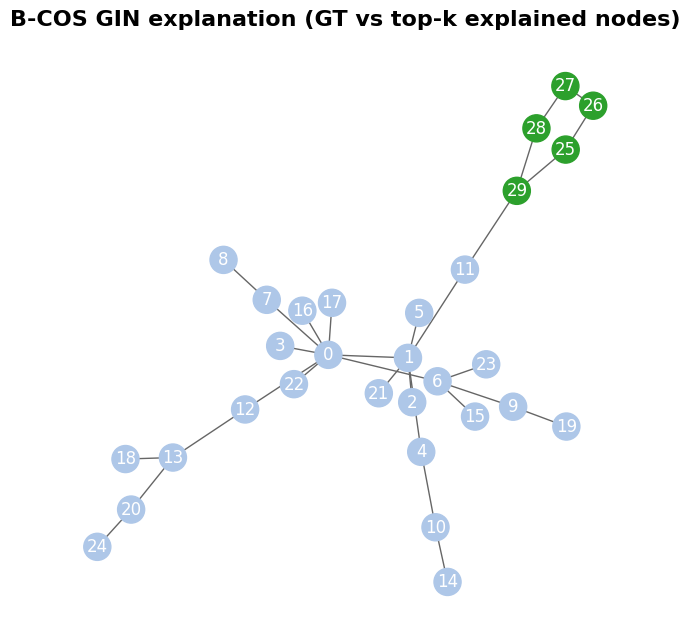

In [16]:
# Quantitative explanation metrics (from bcosgnn.evaluation)
avg_jaccard = evaluate_jaccard(eval_model, test_dataset, method="explain", transform=transform)
avg_auroc = evaluate_auroc(eval_model, test_dataset, method="explain", transform=transform)
print(f"Explanation Jaccard (test): {avg_jaccard:.4f}")
print(f"Explanation AUROC   (test): {avg_auroc:.4f}")

# Single-graph qualitative explanation
sample_idx = 0
data = transform(test_dataset[sample_idx].clone())
batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)

with torch.no_grad():
    pred_logit = eval_model(
        data.x.to(DEVICE),
        data.edge_index.to(DEVICE),
        getattr(data, 'edge_attr', None),
        batch,
    )
pred_class = int(pred_logit.item() > 0)

node_contrib = explain(
    eval_model,
    data.x.to(DEVICE),
    data.edge_index.to(DEVICE),
    getattr(data, 'edge_attr', None),
    batch,
).detach().cpu()

scores = node_contrib.sum(1)
if pred_class == 0:
    scores = -scores

k = int(data.node_mask.sum().item())
topk = torch.topk(scores, k=k).indices if k > 0 else torch.tensor([], dtype=torch.long)
print("Sample index:", sample_idx)
print("Predicted class:", pred_class)
print("Ground-truth motif nodes:", torch.where(data.node_mask.squeeze() == 1)[0].tolist())
print("Top-k explained nodes:", topk.tolist())

g = nx.Graph()
g.add_nodes_from(range(data.num_nodes))
g.add_edges_from(data.edge_index.t().tolist())
pos = nx.spring_layout(g, seed=42)

gt_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].tolist())
pred_nodes = set(topk.tolist())
node_colors = [
    "#2ca02c" if i in gt_nodes and i in pred_nodes
    else "#d62728" if i in gt_nodes
    else "#ff7f0e" if i in pred_nodes
    else "#aec7e8"
    for i in range(data.num_nodes)
]

plt.figure(figsize=(6, 6))
nx.draw(
    g,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=380,
    font_color="white",
    edge_color="#666666",
)
plt.title("B-COS GIN explanation (GT vs top-k explained nodes)")
plt.show()

## Completeness Check

In [17]:
model = model
data = test_dataset[100].clone()

# Apply the degree transform to match training
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
data = transform(data)

node_contributions = explain(
    model,
    data.x,
    data.edge_index,
    torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
).detach()

with torch.no_grad():

    pred = model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long))

In [18]:
pred.sum(), node_contributions.sum()

(tensor(24.7661), tensor(24.7661))

Running Completeness Check: 100%|██████████| 200/200 [00:00<00:00, 799.63it/s]




B-cos Completeness Gap (MAE): 1.62e-06


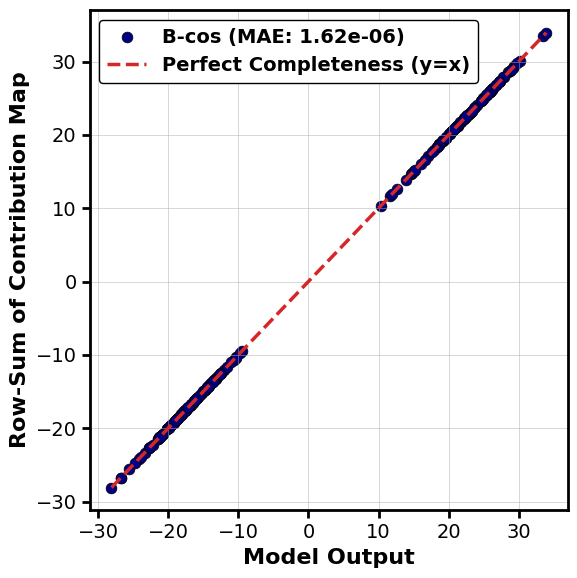

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import functools
from tqdm import tqdm

# --- 1. Publication Quality Global Settings ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (6, 6), 
    'axes.linewidth': 2.0,    
    'font.family': 'sans-serif' 
})

# Assuming `best_model`, `test_dataset`, and `explain` are already in memory
bcos_preds = []
bcos_contrib_sums = []

transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

# Iterate over the entire test set
for data in tqdm(test_dataset, desc="Running Completeness Check"):
    data = transform(data.clone())
    
    # Get Model Prediction
    with torch.no_grad():
        pred = model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long))
        
    # Get B-cos Contributions
    node_contributions = explain(
        model,
        data.x,
        data.edge_index,
        torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long)
    ).detach()
    
    # Store the sum of predictions and the sum of the contribution map M(x)
    bcos_preds.append(pred.sum().item())
    bcos_contrib_sums.append(node_contributions.sum().item())

# Calculate Mean Absolute Error (MAE)
bcos_mae = np.mean(np.abs(np.array(bcos_preds) - np.array(bcos_contrib_sums)))
print(f"\nB-cos Completeness Gap (MAE): {bcos_mae:.2e}")

# --- 2. Plotting the Scatter Plot ---
fig, ax = plt.subplots()

# Plot B-cos data: Darker, fully opaque navy blue with black outlines for readability
ax.scatter(bcos_preds, bcos_contrib_sums, alpha=1.0, s=60, 
           label=f'B-cos (MAE: {bcos_mae:.2e})', color='navy', edgecolors='black', linewidths=0.5)

# Plot the ideal "Perfect Completeness" line (y = x)
min_val = min(min(bcos_preds), min(bcos_contrib_sums))
max_val = max(max(bcos_preds), max(bcos_contrib_sums))
ax.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', 
        linewidth=2.5, label='Perfect Completeness (y=x)')

ax.set_xlabel('Model Output')
ax.set_ylabel('Row-Sum of Contribution Map')

# Configure Legend with bold text and a clean border
legend = ax.legend(loc='upper left', frameon=True, edgecolor='black', framealpha=1.0)
for text in legend.get_texts():
    text.set_weight("bold")

# Thicker grid lines and tick marks
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='both', which='major', width=2.0, length=6)

plt.tight_layout()

# --- 3. Export to PDF ---
# Saves a crisp, vector-based PDF perfect for LaTeX/NeurIPS submission
plt.savefig('completeness_check_ba2motifs.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [21]:
# ── Post-hoc explainer setup ─────────────────────────────────────────────────
# The B-COS GIN outputs a single binary logit [N, 1].
# PyG's Explainer API works more cleanly with a 2-class output [N, 2],
# so we wrap eval_model to produce [-logit, logit] before passing it to the explainer.
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from bcosgnn.evaluation import evaluate_gnnexplainer_jaccard, evaluate_gnnexplainer_auroc

try:
    from torch_geometric.explain import CaptumExplainer
    CAPTUM_AVAILABLE = True
except ImportError:
    CAPTUM_AVAILABLE = False
    print("WARNING: CaptumExplainer not found. IG comparison will be skipped.")


class BCos2ClassAdapter(torch.nn.Module):
    """Wraps a single-logit B-COS eval model into a 2-class [neg, pos] format
    so that PyG Explainer / Captum can use target-class indexing normally."""
    def __init__(self, bcos_eval_model: torch.nn.Module):
        super().__init__()
        self.bcos_eval_model = bcos_eval_model

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        logit = self.bcos_eval_model(x, edge_index, edge_attr, batch)  # [N, 1]
        logit = logit.view(-1, 1)
        return torch.cat([-logit, logit], dim=1)  # [N, 2]: idx 0 = class 0, idx 1 = class 1


def make_gnn_explainer(model_2class, gnn_epochs: int = 200, gnn_lr: float = 0.01):
    return Explainer(
        model=model_2class,
        algorithm=GNNExplainer(epochs=gnn_epochs, lr=gnn_lr),
        explanation_type='model',
        node_mask_type='object',
        edge_mask_type=None,
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='raw',
        ),
    )


def make_ig_explainer(model_2class):
    if not CAPTUM_AVAILABLE:
        raise RuntimeError("CaptumExplainer is not available. Install captum to use IG.")
    return Explainer(
        model=model_2class,
        algorithm=CaptumExplainer('IntegratedGradients'),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type=None,
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',
        ),
    )


def evaluate_ig_on_bcos(ig_explainer, model_2class, dataset, transform=None):
    """Compute Jaccard@|GT| and Node AUROC for IG on the B-COS model.
    IG node scores = sum of absolute feature attributions per node.
    """
    from sklearn.metrics import roc_auc_score as sk_auroc
    jaccards, aurocs = [], []

    for data in tqdm(dataset, desc="Evaluating IG (post-hoc)", leave=True):
        data_t = transform(data.clone()) if transform else data.clone()
        data_t = data_t.to(DEVICE)

        if not hasattr(data_t, 'node_mask') or data_t.node_mask is None:
            continue

        gt_mask = data_t.node_mask.squeeze().detach().cpu().numpy().astype(int)
        k = int(gt_mask.sum())
        batch = torch.zeros(data_t.x.size(0), dtype=torch.long, device=DEVICE)

        with torch.no_grad():
            logits_2cls = model_2class(data_t.x, data_t.edge_index, None, batch)
        pred_class = int(logits_2cls.argmax(dim=-1).item())

        try:
            expl = ig_explainer(
                x=data_t.x,
                edge_index=data_t.edge_index,
                batch=batch,
                target=pred_class,
            )
            # Sum absolute attribution across input features → scalar importance per node
            scores = expl.node_mask.abs().sum(dim=1).detach().cpu().numpy()

            if gt_mask.min() != gt_mask.max():
                aurocs.append(sk_auroc(gt_mask, scores))

            if k > 0:
                top_k = np.argsort(scores)[-k:]
                pred_mask = np.zeros_like(gt_mask)
                pred_mask[top_k] = 1
                inter = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                jaccards.append(inter / union if union > 0 else 0.0)
        except Exception:
            pass

    return (
        float(np.mean(jaccards)) if jaccards else float('nan'),
        float(np.mean(aurocs)) if aurocs else float('nan'),
    )


print("Post-hoc explainer utilities ready.")

Post-hoc explainer utilities ready.


In [22]:
# ── Per-seed post-hoc evaluation ───────────────────────────────────────────
# For each seed's trained B-COS model we run both post-hoc explainers on the
# held-out test split produced during training (same split used for B-COS metrics).
posthoc_results = []

for result in seed_results:
    seed_id = result["seed"]
    eval_m   = result["eval_model"].to(DEVICE)
    test_d   = result["test_dataset"]

    print(f"\n{'='*60}")
    print(f"Seed {seed_id}: post-hoc explainers on B-COS GIN")
    print(f"{'='*60}")

    # Wrap the B-COS eval model to produce 2-class logits
    model_2cls = BCos2ClassAdapter(eval_m).to(DEVICE)
    model_2cls.eval()

    # ── GNNExplainer ────────────────────────────────────────
    gnn_exp  = make_gnn_explainer(model_2cls, gnn_epochs=200, gnn_lr=0.01)
    gnn_jacc = evaluate_gnnexplainer_jaccard(gnn_exp, model_2cls, test_d, transform=transform)
    gnn_auroc = evaluate_gnnexplainer_auroc(gnn_exp, model_2cls, test_d, transform=transform)
    print(f"  GNNExplainer  →  Jaccard: {gnn_jacc:.4f}  |  AUROC: {gnn_auroc:.4f}")

    # ── Integrated Gradients ─────────────────────────────────
    if CAPTUM_AVAILABLE:
        ig_exp = make_ig_explainer(model_2cls)
        ig_jacc, ig_auroc = evaluate_ig_on_bcos(ig_exp, model_2cls, test_d, transform=transform)
        print(f"  IG (Captum)   →  Jaccard: {ig_jacc:.4f}  |  AUROC: {ig_auroc:.4f}")
    else:
        ig_jacc, ig_auroc = float('nan'), float('nan')
        print("  IG (Captum)   →  SKIPPED (captum not installed)")

    posthoc_results.append({
        "seed":       seed_id,
        "gnn_jaccard": float(gnn_jacc),
        "gnn_auroc":   float(gnn_auroc),
        "ig_jaccard":  float(ig_jacc),
        "ig_auroc":    float(ig_auroc),
    })

print("\nPost-hoc evaluation complete.")


Seed 0: post-hoc explainers on B-COS GIN


Evaluating Jaccard (gnnexplainer):   0%|          | 0/200 [00:00<?, ?it/s]/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
Evaluating AUROC (gnnexplainer):   0%|          | 1/200 [00:00<01:01,  3.25it/s]/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
Evaluating AUROC (gnnexplainer):   1%|    

  GNNExplainer  →  Jaccard: 0.3320  |  AUROC: 0.6633


Evaluating IG (post-hoc):   0%|          | 0/200 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
Evaluating IG (post-hoc):   1%|          | 2/200 [00:00<00:10, 18.33it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
Evaluating IG (post-hoc):   1%|          | 2/200 [00:00<00:10, 18.33it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40

  IG (Captum)   →  Jaccard: 0.8335  |  AUROC: 0.9638

Seed 1: post-hoc explainers on B-COS GIN


...

  IG (Captum)   →  Jaccard: 0.7603  |  AUROC: 0.9477

Seed 4: post-hoc explainers on B-COS GIN


Evaluating Jaccard (gnnexplainer):   0%|          | 0/200 [00:00<?, ?it/s]/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
Evaluating AUROC (gnnexplainer):   0%|          | 1/200 [00:00<00:45,  4.40it/s]/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/bcosgnn/evaluation.py:77: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(
Evaluating AUROC (gnnexplainer):   1%|    

  GNNExplainer  →  Jaccard: 0.4121  |  AUROC: 0.7439


Evaluating IG (post-hoc):   0%|          | 0/200 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should not be provided for the explanation type 'model'
  expl = ig_explainer(
Evaluating IG (post-hoc):   2%|▏         | 3/200 [00:00<00:08, 21.99it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_3561/3780056928.py:84: UserWarning: The 'target' should

  IG (Captum)   →  Jaccard: 0.6421  |  AUROC: 0.9244

Post-hoc evaluation complete.


In [24]:
# ── Comparison table ───────────────────────────────────────────────
# All three methods evaluated on the same B-COS GIN model and the same test splits.
def _ms(vals):
    """Return mean ± std string, ignoring NaN values."""
    vals = np.asarray([v for v in vals if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return "N/A"
    std = vals.std(ddof=1) if len(vals) > 1 else 0.0
    return f"{vals.mean():.4f} ± {std:.4f}"


bcos_jacc  = [r["test_jaccard"]    for r in seed_results]
bcos_auroc = [r["test_expl_auroc"] for r in seed_results]

gnn_jacc  = [r["gnn_jaccard"] for r in posthoc_results]
gnn_auroc = [r["gnn_auroc"]   for r in posthoc_results]

ig_jacc  = [r["ig_jaccard"] for r in posthoc_results]
ig_auroc = [r["ig_auroc"]   for r in posthoc_results]

comparison_df = pl.DataFrame([
    {
        "Method":         "B-COS Intrinsic",
        "Model":          "B-COS GIN",
        "Explainer":      "Linear decomposition (explain.py)",
        "Jaccard@|GT|": _ms(bcos_jacc),
        "Node AUROC":   _ms(bcos_auroc),
    },
    {
        "Method":         "GNNExplainer (post-hoc)",
        "Model":          "B-COS GIN",
        "Explainer":      "PyG GNNExplainer (200 epochs)",
        "Jaccard@|GT|": _ms(gnn_jacc),
        "Node AUROC":   _ms(gnn_auroc),
    },
    {
        "Method":         "IG (post-hoc)",
        "Model":          "B-COS GIN",
        "Explainer":      "Captum IntegratedGradients",
        "Jaccard@|GT|": _ms(ig_jacc),
        "Node AUROC":   _ms(ig_auroc),
    },
])

print("=" * 70)
print("Explanation Quality Comparison on Custom BA2Motif (B-COS GIN Model)")
print(f"Across {len(seed_results)} seeds, mean ± std")
print("=" * 70)
display(comparison_df)

Explanation Quality Comparison on Custom BA2Motif (B-COS GIN Model)
Across 5 seeds, mean ± std


Method,Model,Explainer,Jaccard@|GT|,Node AUROC
str,str,str,str,str
"""B-COS Intrinsic""","""B-COS GIN""","""Linear decomposition (explain.…","""0.9050 ± 0.0500""","""0.9908 ± 0.0048"""
"""GNNExplainer (post-hoc)""","""B-COS GIN""","""PyG GNNExplainer (200 epochs)""","""0.3216 ± 0.0629""","""0.6621 ± 0.0516"""
"""IG (post-hoc)""","""B-COS GIN""","""Captum IntegratedGradients""","""0.7452 ± 0.0712""","""0.9458 ± 0.0169"""
